# ES Futures Roll Analysis — EDA

Loads the four `ohlcv-1d` parquet files (one per quarterly roll) from the external drive and visualizes:
1. **Volume migration** — front vs back daily volume, crossover annotated
2. **Calendar spread** — back-month close minus front-month close
3. **Crossover summary** — detected roll windows across all pairs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
DATA_DIR = Path('/Volumes/SEAGATE/Databento_Futures')

PAIRS = [
    ('ESU4', 'ESZ4', '2024-08'),
    ('ESZ4', 'ESH5', '2024-11'),
    ('ESH5', 'ESM5', '2025-02'),
    ('ESM5', 'ESU5', '2025-05'),
]

frames = {}
for front, back, month in PAIRS:
    path = DATA_DIR / f'ohlcv1d_{front}_{back}_{month}.parquet'
    df = pd.read_parquet(path)
    frames[(front, back)] = df
    print(f'{front}/{back}:  {len(df):>3} rows   {df.index.min().date()} → {df.index.max().date()}')

ESU4/ESZ4:   50 rows   2024-08-22 → 2024-09-19
ESZ4/ESH5:   50 rows   2024-11-21 → 2024-12-19
ESH5/ESM5:   50 rows   2025-02-20 → 2025-03-20
ESM5/ESU5:   50 rows   2025-05-22 → 2025-06-19


## Data inspection

In [3]:
sample = frames[('ESU4', 'ESZ4')]
print(sample.dtypes)
print()
display(sample.head(10))

rtype              uint8
publisher_id      uint16
instrument_id     uint32
open             float64
high             float64
low              float64
close            float64
volume            uint64
symbol               str
dtype: object



,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2024-08-22 00:00:00+00:00,35,1,183748,5704.00,5724.75,5643.25,5664.50,1979,ESZ4
2024-08-22 00:00:00+00:00,35,1,118,5645.00,5665.25,5582.75,5604.50,1328958,ESU4
2024-08-23 00:00:00+00:00,35,1,183748,5665.25,5723.00,5662.75,5711.00,2962,ESZ4
2024-08-23 00:00:00+00:00,35,1,118,5604.75,5662.25,5602.75,5650.75,1338049,ESU4
2024-08-25 00:00:00+00:00,35,1,183748,5713.00,5719.25,5700.25,5705.25,248,ESZ4
2024-08-25 00:00:00+00:00,35,1,118,5650.50,5659.25,5640.25,5646.50,16928,ESU4
2024-08-26 00:00:00+00:00,35,1,118,5646.50,5669.00,5619.75,5632.00,1050101,ESU4
2024-08-26 00:00:00+00:00,35,1,183748,5707.00,5729.25,5680.50,5692.00,1932,ESZ4
2024-08-27 00:00:00+00:00,35,1,183748,5695.25,5709.75,5673.00,5697.00,1952,ESZ4


## Volume migration — all four roll periods

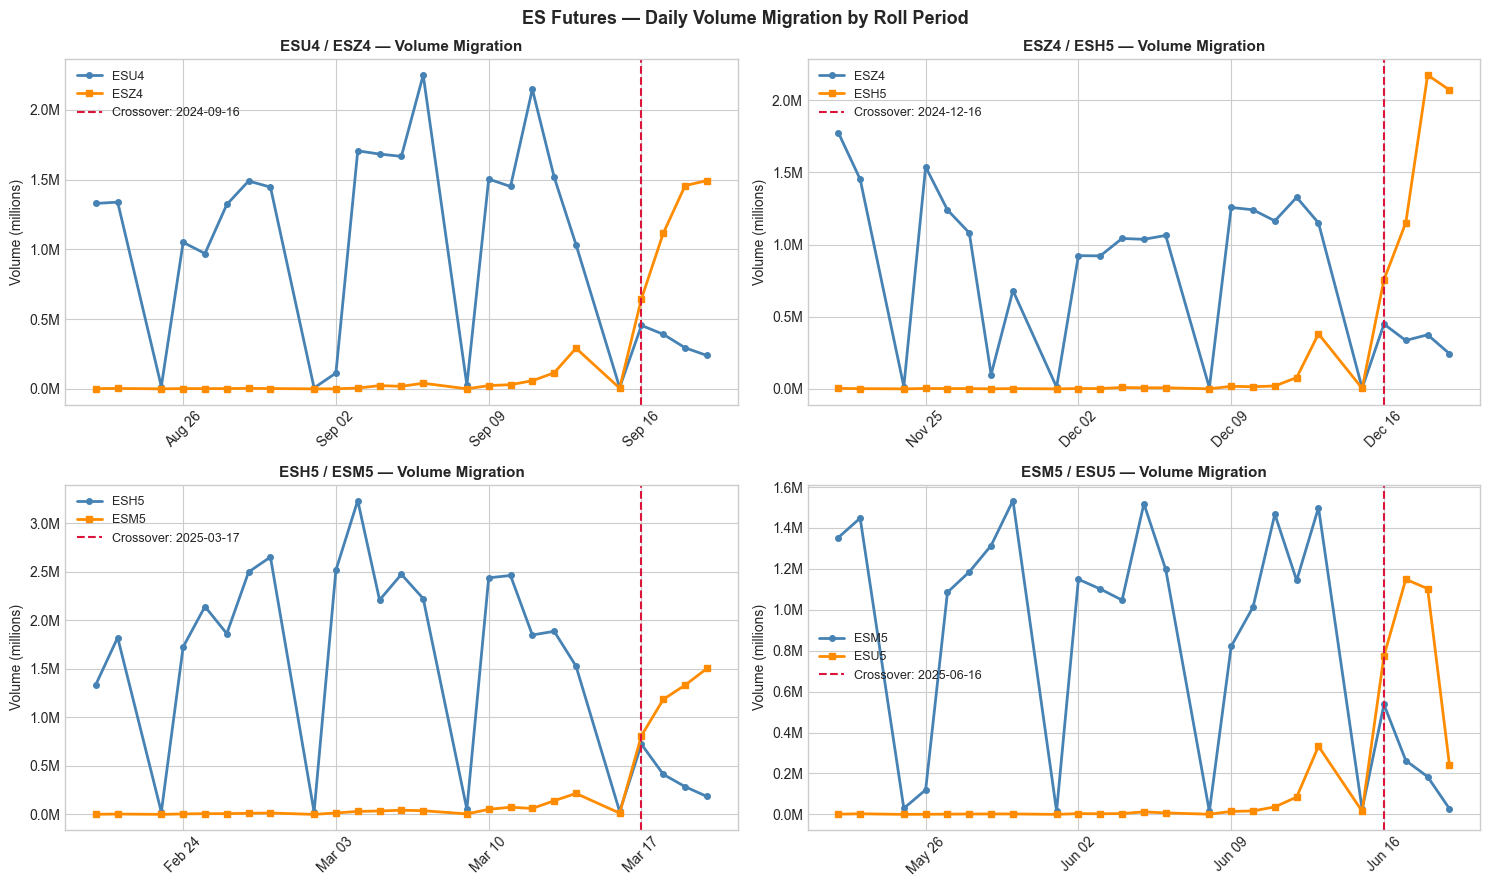

In [4]:
def build_daily_volume(df, front, back):
    """Pivot ohlcv-1d frame to daily volume per symbol."""
    return (
        df.reset_index()
        .assign(date=lambda x: x['ts_event'].dt.date)
        .groupby(['date', 'symbol'])['volume']
        .sum()
        .unstack('symbol')
        .fillna(0)
        .reindex(columns=[front, back])
    )

def detect_crossover(vol, front, back):
    """First date where back-month volume >= front-month volume."""
    if front not in vol.columns or back not in vol.columns:
        return None
    mask = vol[back] >= vol[front]
    return vol.index[mask][0] if mask.any() else None


fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()
crossovers = {}  # store for summary table

for ax, ((front, back), df) in zip(axes, frames.items()):
    vol = build_daily_volume(df, front, back)
    crossover = detect_crossover(vol, front, back)
    crossovers[(front, back)] = crossover

    dates = [pd.Timestamp(d) for d in vol.index]

    ax.plot(dates, vol[front] / 1e6, label=front, color='steelblue',
            linewidth=2, marker='o', markersize=4)
    ax.plot(dates, vol[back]  / 1e6, label=back,  color='darkorange',
            linewidth=2, marker='s', markersize=4)

    if crossover is not None:
        ax.axvline(pd.Timestamp(crossover), color='crimson', linestyle='--',
                   linewidth=1.5, label=f'Crossover: {crossover}')

    ax.set_title(f'{front} / {back} — Volume Migration', fontsize=11, fontweight='bold')
    ax.set_ylabel('Volume (millions)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

fig.suptitle('ES Futures — Daily Volume Migration by Roll Period', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Calendar spread — back-month close minus front-month close

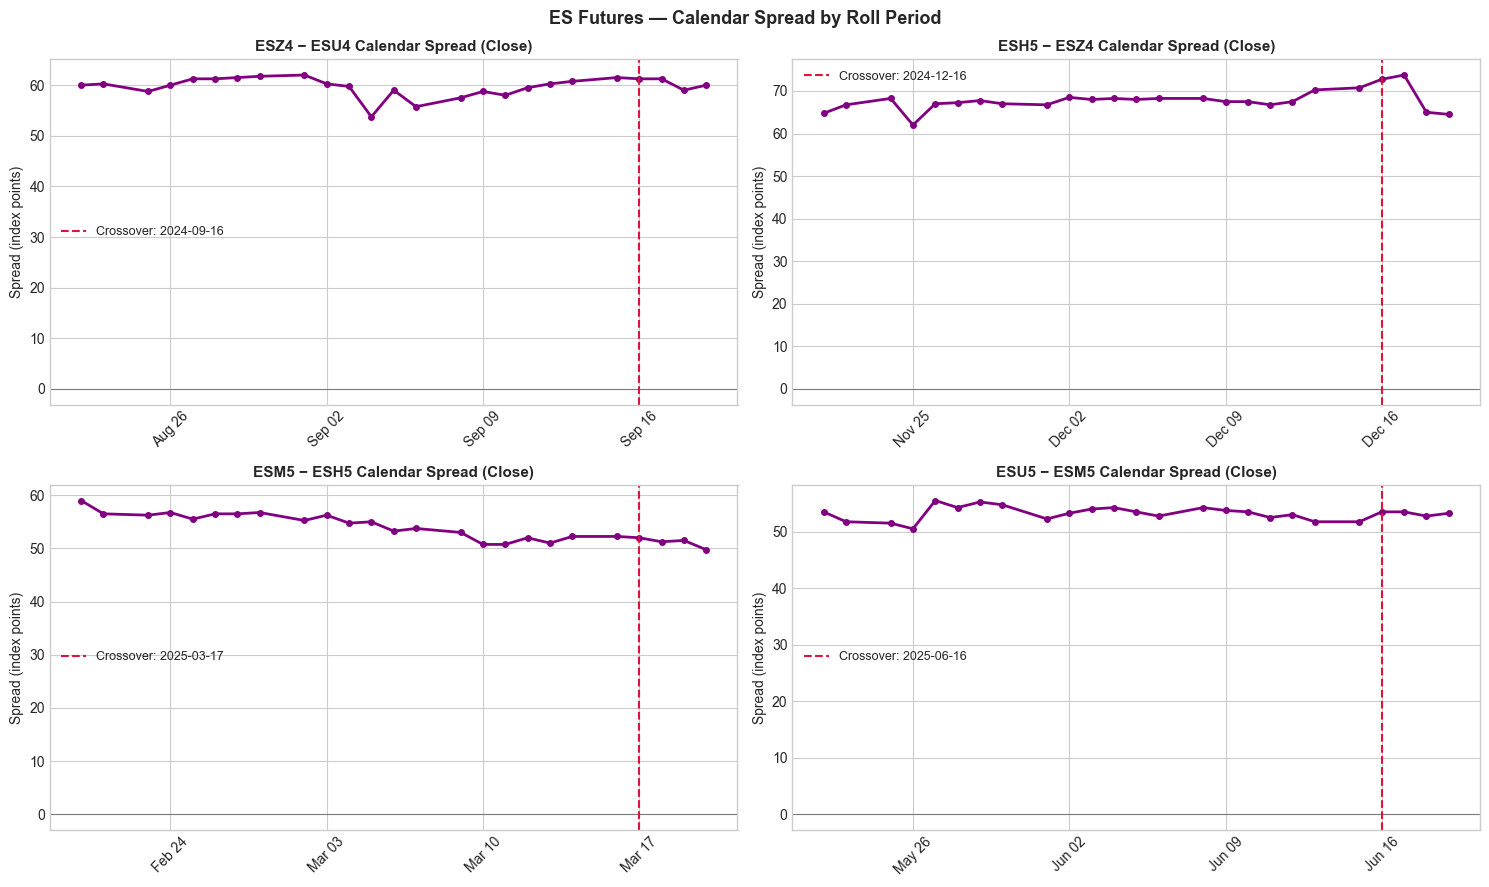

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, ((front, back), df) in zip(axes, frames.items()):
    close = (
        df.reset_index()
        .assign(date=lambda x: x['ts_event'].dt.date)
        .groupby(['date', 'symbol'])['close']
        .last()
        .unstack('symbol')
        .reindex(columns=[front, back])
    )

    spread = close[back] - close[front]
    dates = [pd.Timestamp(d) for d in spread.index]
    crossover = crossovers.get((front, back))

    ax.plot(dates, spread.values, color='purple', linewidth=2, marker='o', markersize=4)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-', alpha=0.4)

    if crossover is not None:
        ax.axvline(pd.Timestamp(crossover), color='crimson', linestyle='--',
                   linewidth=1.5, label=f'Crossover: {crossover}')
        ax.legend(fontsize=9)

    ax.set_title(f'{back} − {front} Calendar Spread (Close)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Spread (index points)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('ES Futures — Calendar Spread by Roll Period', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Crossover summary

In [6]:
from datetime import timedelta

DAYS_BEFORE = 2
DAYS_AFTER  = 3

def next_biz_day(d, n):
    step = 1 if n >= 0 else -1
    count = abs(n)
    while count > 0:
        d += timedelta(days=step)
        if d.weekday() < 5:
            count -= 1
    return d

rows = []
for (front, back), crossover in crossovers.items():
    if crossover is not None:
        roll_start = next_biz_day(crossover, -DAYS_BEFORE)
        roll_end   = next_biz_day(crossover,  DAYS_AFTER)
        status = 'detected'
    else:
        roll_start = roll_end = None
        status = 'FALLBACK — widen search window'

    rows.append({
        'Pair':       f'{front}/{back}',
        'Crossover':  str(crossover),
        'Roll Start': str(roll_start),
        'Roll End':   str(roll_end),
        'Window (biz days)': f'{DAYS_BEFORE}+{DAYS_AFTER}',
        'Status':     status,
    })

display(pd.DataFrame(rows).set_index('Pair'))

,Crossover,Roll Start,Roll End,Window (biz days),Status
Pair,,,,,
ESU4/ESZ4,2024-09-16,2024-09-12,2024-09-19,2+3,detected
ESZ4/ESH5,2024-12-16,2024-12-12,2024-12-19,2+3,detected
ESH5/ESM5,2025-03-17,2025-03-13,2025-03-20,2+3,detected
ESM5/ESU5,2025-06-16,2025-06-12,2025-06-19,2+3,detected
